# Optimal planetary landing

<style>
.MathJax {
  font-family: "Common HTML";
}
</style>

$$
\newcommand{\eg}{{\it e.g.}}
\newcommand{\ie}{{\it i.e.}}
\newcommand{\argmin}{\mathrm{argmin}}
\newcommand{\mc}{\mathcal}
\newcommand{\mb}{\mathbb}
\newcommand{\mf}{\mathbf}
\newcommand{\minimize}{{\text{minimize}}}
\newcommand{\diag}{{\text{diag}}}
\newcommand{\cond}{{\text{cond}}}
\newcommand{\rank}{{\text{rank }}}
\newcommand{\range}{{\mathcal{R}}}
\newcommand{\null}{{\mathcal{N}}}
\newcommand{\tr}{{\text{trace}}}
\newcommand{\dom}{{\text{dom}}}
\newcommand{\dist}{{\text{dist}}}
\newcommand{\R}{\mathbf{R}}
\newcommand{\SM}{\mathbf{S}}
\newcommand{\ball}{\mathcal{B}}
\newcommand{\bmat}[1]{\begin{bmatrix}#1\end{bmatrix}}
\newcommand{\loss}{\ell}
\newcommand{\eloss}{\mc{L}}
\newcommand{\abs}[1]{| #1 |}
\newcommand{\norm}[1]{\| #1 \|}
\newcommand{\tp}{T}
$$

__<div style="text-align: right"> ASE3001: Computational Experiments for Aerospace Engineering, Inha University. </div>__
_<div style="text-align: right"> Jong-Han Kim (jonghank@inha.ac.kr) </div>_
_<div style="text-align: right"> Jiwoo Choi (jiwoochoi@inha.edu) </div>_

<br>

---

<br>

## Optimal landing guidance

In this problem we consider a soft landing problem for a planetary lander.

Consider the following equations of motion in the ENU (East-North-Up) frame

$$
\begin{aligned}
  \dot{p} &= v \\  
  \dot{v} &= u - \gamma v +g  \\
\end{aligned}
$$
with
$$
\begin{aligned}
    p &= (p_e, p_n, p_u)\\
    v &= (v_e, v_n, v_u) \\
        g&=(0,0,-g).
\end{aligned}
$$

where $p$ and $v$ are the position and velocity of the vehicle and $u$ represents the acceleration of the vehicle. The gravitational acceleration is denoted by $g$ and the damping coefficient is given by $\gamma$. Note that the acceleration vector as the control input can be achieved by a set of thrusters attached on the vehicle. The objective of the problem is to find the control input plan $u_0, \dots, u_{N-1}$ that drives the vehicle to $p=0$ and $v=0$ at $t=N$, from the specified initial condition.

<br>

The above system can be descretized using trapezoidal integration as follows.

$$
\begin{aligned}
  v_{t+1} &= v_t + {h}\left( u_t - \gamma v_t -g \right) \\
  &= \left(1-\gamma h\right) v_t + h u_t - hg \\
  p_{t+1} &= p_t + \frac{h}{2}\left( v_t + v_{t+1} \right)  \\
  &= p_t + \frac{h}{2}\left( v_t + \left(1-\gamma h\right) v_t + h u_t \right)  \\
  &= p_t +  \left(h-\frac{1}{2}\gamma h^2\right) v_t + \frac{1}{2} h^2 u_t
\end{aligned}
$$


Given initial points and desired points, the problem of minimizing the control input while satisfying the  dynamics of the system can be defined as follows,

$$
\begin{aligned}
    \text{minimize} \quad & \sum_{t=0}^{N-1} \left\|u_t \right\|_2^2 \\
    \text{subject to} \quad & x_{t+1} = Ax_t + Bu_t+b , \quad t=0,\dots,N-1,\\
    &x_0 = x_\text{init},\\
    &x_N = x_\text{des},
\end{aligned}
$$

where $N$ is the prediction horizon, which represents the number of future time steps considered for the optimization problem.

The above optimal control problem can be addressed using a weighted least squares approach.

In [1]:
import numpy as np
import numpy.linalg as lg

import scipy.sparse as sp
import scipy.sparse.linalg as sla

import matplotlib.pyplot as plt

import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from dataclasses import dataclass
from tqdm import tqdm

In [2]:
N = 100
T = 10
dt = T / N

gamma = 1e-5
g     = np.array([0, 0, -9.8])

#x_init = np.array([80,-50,350, 2,-3,-0])  # initial pe, pn, pu, ve, vn, vu at t=0
x_init = np.array([10,-5,50, 0,-1,-1])  # initial pe, pn, pu, ve, vn, vu at t=0
x_des  = np.array([0,0,0,0,0,-0.1])      # desired pe, pn, pu, ve, vn, vu at t=N

<br>

---

<br>

_**(Problem 1)**_ Construct the appearing matrices and a vector, $A$, $B$, and $b$ expressed with given parameters. Define $x = (p_e, p_n, p_u, v_e, v_n, v_u)$, and $u=(u_e, u_n, u_u)$.

In [3]:
## your code here ##
h = dt

A = np.zeros((6, 6))
B = np.zeros((6, 3))
b = np.zeros(6)

A[:3, :3] = np.eye(3)
A[:3, 3:] = h*(1-gamma*h/2)*np.eye(3)
A[3:, 3:] = (1-gamma*h)*np.eye(3)

B[:3, :] = 0.5*(h**2)*np.eye(3)
B[3:, :] = h*np.eye(3)

b[:3] = 0
b[3:] = h*g

<br>

---

<br>

_**(Problem 2)**_
The original problem can be reformulated as minimizing a sum of square terms as follows.

$$
\underset{x_1,\dots,x_N, u_0,\dots,u_{N-1}}{\text{minimize}} \ \|x_N-x_\text{des}\|^2 + \sum_{t=0}^{N-1}\left\| x_{t+1}-Ax_{t}-Bu_{t}-b\right\|^2 + \sum_{t=0}^{N-1}\left\|Q_u u_t\right\|^2.
$$

Stacking the state variables and the control inputs by $x = (x_1,x_2, \dots, x_N)$, $u = (u_0, u_1, \dots, u_{N-1})$, and $y = (x, u) \in \R^{9N}$, the above problem can be expressed as the following,

$$
\underset{y}{\text{minimize}} \ \left\|Gy - c\right\|^2 + \sum_{t=0}^{N-1}\left\|Q_u u_t\right\|^2,
$$

which can again be reformulated in,

$$
\underset{y}{\text{minimize}} \ \left\|\tilde{G}y - \tilde{c}\right\|^2  ,
$$

where, $Q_u$ is a weighting matrix that regulates the size of control inputs, which in given in the code cell below.

<br>

Construct $G, \tilde{G}, c, \tilde{c}$ and make a code implementing these, noting that $G, \tilde{G}, c, \tilde{c}$ contain $A$, $B$, $b$, and $I$ (the identity matrix).

Note that the state variables $x_1, \dots, x_N$ appear in the above formulation. In other words, the decision variables of the above problem include not only the control inputs but also the state variables.

Try using the `scipy.sparse` module with indexing where possible.

In [4]:
w_u = 3e-2
Q_u = np.diag([w_u]*3)

In [5]:
## your code here ##
import scipy.sparse as sp
from tqdm import tqdm

n_x = A.shape[0]    # (number of size x : 6)
n_u = B.shape[1]    # (number of size u : 3)
n_y = N * n_x + N * n_u   # len of y = 9N

G = sp.lil_matrix(((N+1) * n_x, n_y))
c = np.zeros((N+1) * n_x)

for t in tqdm(range(N+1)):
    row_start = t * n_x
    row_end   = (t + 1) * n_x

    u_start_idx = N * n_x

    if t == 0:
        # 초기 조건: x_1 - B u_0 = A x_init + b
        c[row_start:row_end]  = A @ x_init + b
        G[row_start:row_end, 0:n_x] = np.eye(n_x) # x_1
        G[row_start:row_end, u_start_idx : u_start_idx + n_u] = -B # -u_0

    elif t < N:
        # 동역학 제약: x_{t+1} - A x_t - B u_t = b
        c[row_start:row_end]  = b
        G[row_start:row_end, t*n_x : (t+1)*n_x] = np.eye(n_x)     # x_{t+1}
        G[row_start:row_end, (t-1)*n_x : t*n_x] = -A              # -x_t

        # u_t 인덱스 주의: N*n_x + t*n_u
        u_idx = u_start_idx + t * n_u
        G[row_start:row_end, u_idx : u_idx + n_u] = -B            # -u_t

    elif t == N:
        G[row_start:row_end, (N-1)*n_x : N*n_x] = np.eye(n_x)     # x_N
        c[row_start:row_end] = x_des
print("Building Augmented Matrix G_tilde...")

total_rows = len(c) + N * n_u
G_tilt = sp.lil_matrix((total_rows, n_y))
C_tilt = np.zeros(total_rows)

G_tilt[:len(c), :] = G
C_tilt[:len(c)] = c

for i in tqdm(range(N)):
    row_idx = len(c) + i * n_u
    col_idx = N * n_x + i * n_u

    # 식: Q_u * u_i = 0 (최소화)
    G_tilt[row_idx : row_idx + n_u, col_idx : col_idx + n_u] = Q_u


100%|██████████| 101/101 [00:00<00:00, 4829.89it/s]


Building Augmented Matrix G_tilde...


100%|██████████| 100/100 [00:00<00:00, 16505.21it/s]


<br>

---

<br>

_**(Problem 3)**_
Find the optimal solution  $y^*$ to the problem using the gradient descent method. Compare this solution with the one obtained via the closed-form solution. Use the initial value `yp_init` specified in the code cell below to achieve faster convergence.

Display the optimal trajectories and the optimal control inputs. Also, check the convergence profile by examining how fast the magnitude of the gradient vectors decreases as the iterations proceed.

In [6]:
xp_init = np.linspace(x_init, x_des, num=N+1, endpoint=True)
yp_init = np.hstack([xp_init[1:].reshape(-1), *[g]*N])[:,None] # initial values

lr = 1e-1
eps_crt = 1e-4  # terminal condition of gradient descent
epochs = 300000

In [7]:
import jax
import jax.numpy as jnp
from jax import jit, grad
from tqdm import tqdm

G_dense = jnp.array(G_tilt.toarray())
c_jax   = jnp.array(C_tilt)
y_start = jnp.array(yp_init.flatten())

@jit
def loss_fn(y):
    res = G_dense @ y - c_jax      # residual
    return jnp.dot(res, res) #  ||res||^2

@jit
def gd_step(y, lr):
    g = grad(loss_fn)(y)           # ∇f(y)
    y_new = y - lr * g             # gradient descent update
    g_norm = jnp.linalg.norm(g)    # gradient norm
    return y_new, g_norm

y_curr = y_start
grad_norms = []

for k in tqdm(range(epochs)):
    y_curr, g_norm = gd_step(y_curr, lr)

    g_val = float(g_norm)
    grad_norms.append(g_val)

    if g_val < eps_crt:
        print(f"Converged at iteration {k}, grad norm = {g_val:.3e}")
        break

if grad_norms:
    print(f"Final gradient norm: {grad_norms[-1]:.3e}")
else:
    print("No GD iterations were performed (check epochs).")

# --- 5.  ---
y_gd = np.array(y_curr) # 최종 해를 NumPy로 변환 및 궤적 복원
x_gd = np.vstack([x_init, y_gd[:N*n_x].reshape(N, n_x)])
u_gd = y_gd[N*n_x:].reshape(N, n_u)

 96%|█████████▋| 289326/300000 [02:45<00:06, 1744.99it/s]

Converged at iteration 289326, grad norm = 1.000e-04
Final gradient norm: 1.000e-04


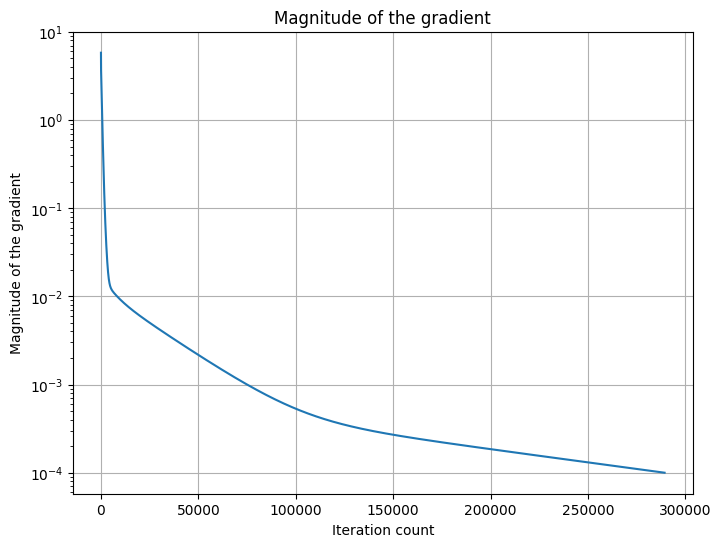

In [16]:
## your code here ##

plt.figure(figsize=(8, 6))
plt.plot(range(len(grad_norms)), grad_norms)
plt.yscale('log')
plt.xlabel("Iteration count")
plt.ylabel("Magnitude of the gradient")
plt.title("Magnitude of the gradient")
plt.grid(True)
plt.show()


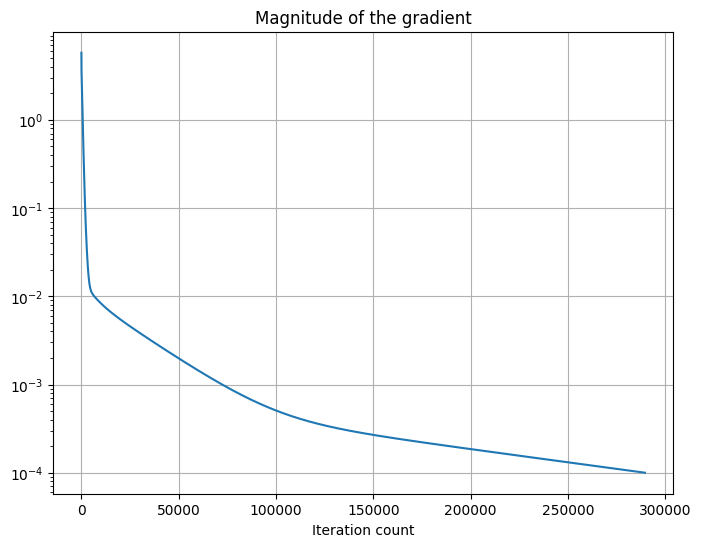

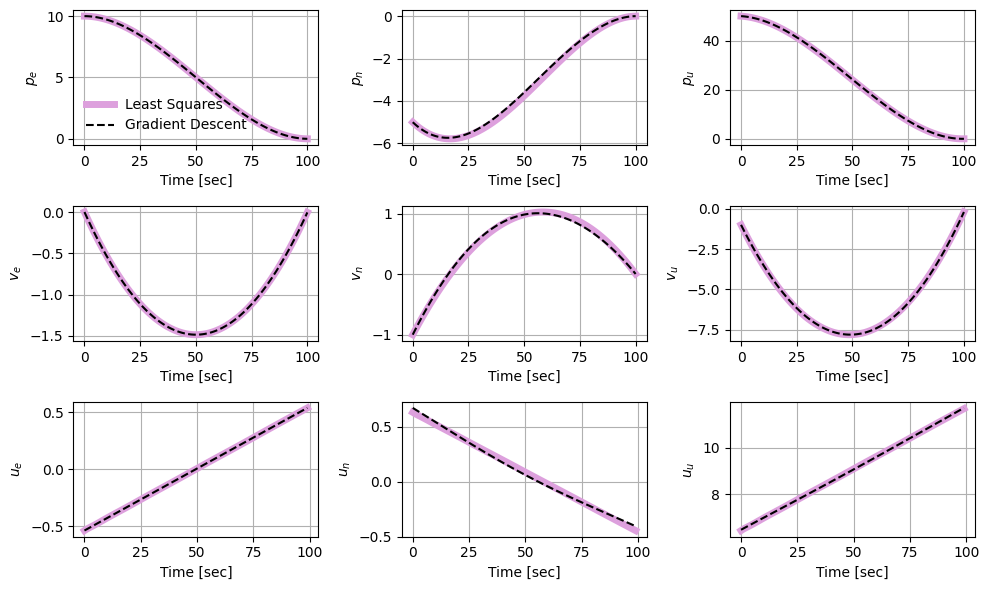

In [9]:
## your code here ##

t_state = np.linspace(0, N, N+1)   # 상태: x_0..x_N, 총 N+1점
t_ctrl  = np.linspace(0, N-1, N)   # 제어: u_0..u_{N-1}, 총 N점

y_ls = sla.lsqr(G_tilt, C_tilt)[0]
x_ls = np.vstack([x_init, y_ls[:N*n_x].reshape(N, n_x)])
u_ls = y_ls[N*n_x:].reshape(N, n_u)

fig, axs = plt.subplots(3, 3, figsize=(10, 6))

items = [
    (r"$p_e$", x_ls[:,0], x_gd[:,0], t_state),
    (r"$p_n$", x_ls[:,1], x_gd[:,1], t_state),
    (r"$p_u$", x_ls[:,2], x_gd[:,2], t_state),
    (r"$v_e$", x_ls[:,3], x_gd[:,3], t_state),
    (r"$v_n$", x_ls[:,4], x_gd[:,4], t_state),
    (r"$v_u$", x_ls[:,5], x_gd[:,5], t_state),
    (r"$u_e$", u_ls[:,0], u_gd[:,0], t_ctrl),
    (r"$u_n$", u_ls[:,1], u_gd[:,1], t_ctrl),
    (r"$u_u$", u_ls[:,2], u_gd[:,2], t_ctrl),
]

for idx, (name, ls_traj, gd_traj, tt) in enumerate(items):
    r, c = divmod(idx, 3)
    ax = axs[r, c]
    ax.plot(tt, ls_traj, color="plum", linewidth=5, label="Least Squares")
    ax.plot(tt, gd_traj, "k--", linewidth=1.5, label="Gradient Descent")
    ax.set_xlabel("Time [sec]")
    ax.set_ylabel(name)
    ax.grid(True)
    if idx == 0:
        ax.legend(frameon=False)

fig.tight_layout()
plt.show()

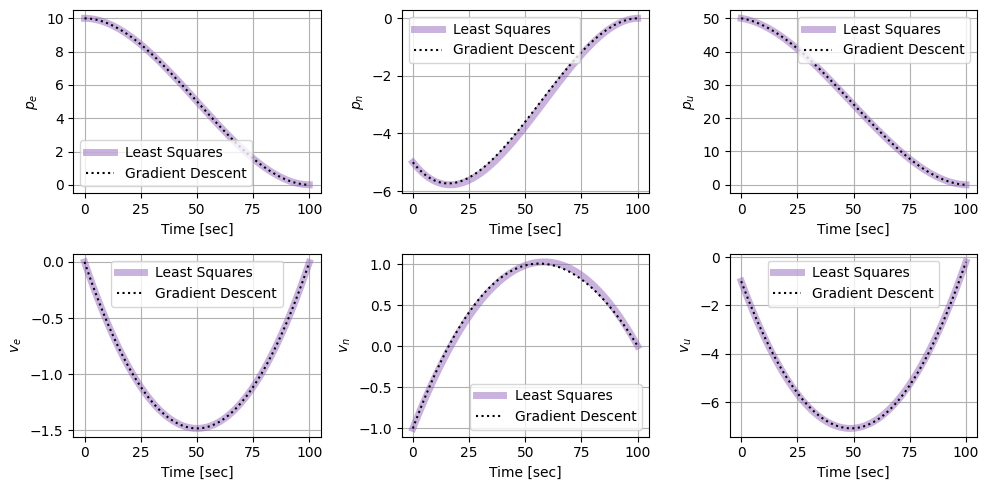
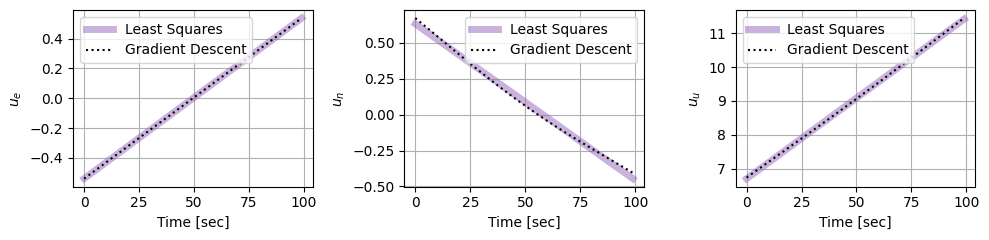

<br>

---

<br>

## Optimal Control Under Constraints

Optimal control problems often involve constraints that limit the possible values of control inputs and/or states. These constraints are crucial for ensuring that the obtained solution is physically realizable, safe, and adheres to operational limitations.

### Types of Constraints:
*   **Control Input Limits**: These define the maximum and minimum values that the control inputs (e.g., thrust, acceleration) can take. For a planetary lander, this might mean limits on the thruster magnitude or direction due to hardware capabilities.
    $$u_{\text{min}} \leq u_t \leq u_{\text{max}}$$
*   **State Bounds**: These define the allowable range for the state variables (e.g., position, velocity). For instance, the lander's position might be constrained to be above a certain altitude, or its velocity might have a maximum limit for structural integrity.
    $$x_{\text{min}} \leq x_t \leq x_{\text{max}}$$
*   **Terminal Constraints**: These are specific conditions that must be met at the end of the trajectory, such as reaching a specific position and velocity (as in our soft landing problem where $x_N = x_{\text{des}}$).

### Significance of Constraints:
Constraints are vital because they:
*   **Reflect Physical Reality**: They ensure the solution respects the real-world limitations of the system. Without them, an optimizer might suggest impossibly large control forces or states.
*   **Ensure Safety**: They can prevent the system from entering unsafe operating regimes (e.g., crashing, exceeding structural limits).
*   **Define Operational Envelopes**: They specify the boundaries within which the system is designed to operate effectively.
*   **Impact Solution Feasibility**: Including constraints can significantly alter the optimal trajectory and control sequence, making the problem more challenging but leading to a practical solution.

<br>

---

<br>

## Projected Gradient Descent

### Projected Gradient Descent (PGD)

Projected Gradient Descent is an iterative optimization algorithm used to find the minimum of a function subject to constraints. It extends the standard gradient descent method by incorporating a projection step to ensure that the updated solution remains within the feasible set defined by the constraints.

The algorithm proceeds in two main steps at each iteration:

1.  **Gradient Descent Step (Unconstrained Step):** In this step, a standard gradient descent update is performed without considering any constraints. The objective is to move in the direction that most rapidly decreases the function value.

    Mathematically, given the current iterate $x^{(k)}$ and the objective function $f(x)$, the unconstrained step computes a candidate next iterate $\tilde{x}^{(k+1)}$ as:

    $$\tilde{x}^{(k+1)} = x^{(k)} - \alpha \nabla f(x^{(k)})$$

    where $\alpha > 0$ is the learning rate (step size), and $\nabla f(x^{(k)})$ is the gradient of the objective function at $x^{(k)}$.

2.  **Projection Step:** After the unconstrained gradient step, the candidate solution $\tilde{x}^{(k+1)}$ might lie outside the feasible set. The projection step then maps $\tilde{x}^{(k+1)}$ back onto the feasible set to satisfy the constraints. The projection typically finds the point within the feasible set that is closest to $\tilde{x}^{(k+1)}$.

    Mathematically, the projection is denoted by $P_{{C}}(\cdot)$, where ${C}$ is the feasible set. The projected iterate $x^{(k+1)}$ is given by:

    $$x^{(k+1)} = P_{{C}}(\tilde{x}^{(k+1)})$$

    The projection $P_{{C}}(y)$ is formally defined as:

    $$P_{{C}}(y) = \argmin_{z \in {C}} \|z - y\|_2^2$$

    This ensures that $x^{(k+1)}$ is the closest point in the feasible set ${C}$ to $\tilde{x}^{(k+1)}$.

By repeatedly applying these two steps, Projected Gradient Descent iteratively refines the solution, moving towards the minimum of the function while always staying within the defined constraints. The convergence properties of PGD are similar to those of standard gradient descent, but with the added complexity and computational cost of the projection step.

## Control Constraints


The minimum and maximum allowable values for the control input `u` are given below as NumPy arrays `u_min` and `u_max` respectively.



In [10]:
u_min = np.array([-0.5, -0.5, 0])
u_max = np.array([0.5, 0.5, 10])

<br>

---

<br>

_**(Problem 4)**_
Implement a Python function `project_onto_feasible_set()` that performs the projection operation onto the feasible set defined by the control input constraints. This function will take the full solution vector `y` and apply clipping based on `u_min` and `u_max` to the control input portion of `y`.


In [11]:
def project_onto_feasible_set(y):

    ## your code here ##
    y_flat = np.asarray(y).reshape(-1)
    x_part = y_flat[:6 * N]
    u_part = y_flat[6 * N:]

    # 제어 입력을 shape (N,3)로 바꾼 뒤 각 축별로 클리핑
    u_clipped = np.clip(u_part.reshape(N, 3), u_min, u_max).reshape(-1)

    y_projected = np.concatenate([x_part, u_clipped])   # 결합

    ## your code here ##

    return y_projected

<br>

---

<br>

_**(Problem 5)**_
Implement the Projected Gradient Descent (PGD) algorithm to find the optimal solution `y_pgd`, incorporating the `project_onto_feasible_set` function.

#### Instructions
1. Initialize `y_pgd` with `yp_init`.
2. In each iteration of the gradient descent loop:
    a. Calculate the gradient `grad` using `func_grad`.
    b. Perform the unconstrained gradient descent step to get `y_new_unconstrained`.
    c. Apply the `project_onto_feasible_set` function to `y_new_unconstrained` to get `y_new_pgd`, ensuring constraints are met.
    d. Update `y_pgd` with `y_new_pgd`.
    e. Store the norm of the gradient for convergence plotting.
    f. Break the loop if the gradient norm falls below `eps_crt`.

<br>

After you implement the PGD algorithm, visualize its convergence profile by plotting the magnitude of the gradient over iterations, similar to the previous gradient descent plot. This will show how quickly the algorithm converged.

<br>

In addition, visualize the resulting optimal trajectories (states) and control inputs, and compare them with the previously calculated solutions (unconstrained GD and closed-form least norm solution). This will demonstrate the effect of the constraints.

In [12]:
## your code here ##
from jax import grad

grad_loss = grad(loss_fn)

def func_grad(y_np: np.ndarray) -> np.ndarray:
    y_jax = jnp.array(y_np)          # numpy -> jax
    g_jax = grad_loss(y_jax)         # JAX gradient
    return np.asarray(g_jax)         # jax -> numpy


lr_pgd = lr
y_pgd  = np.asarray(yp_init, dtype=float).ravel()

grads_pgd = []
losses_pgd = []

for k in tqdm(range(epochs)):
    g = func_grad(y_pgd)
    gnorm = float(np.linalg.norm(g))
    grads_pgd.append(gnorm)

    # 수렴 판정
    if gnorm < eps_crt:
        print(f"PGD converged at iter {k}, grad norm = {gnorm:.3e}")
        break

    # unconstrained gradient step
    y_unconstrained = y_pgd - lr_pgd * g

    # control 제약을 반영한 projection
    y_pgd = project_onto_feasible_set(y_unconstrained)


# y_pgd를 상태/제어 궤적으로 복원
x_pgd = y_pgd[:N * 6].reshape(N, 6)
u_pgd = y_pgd[N * 6:].reshape(N, 3)
x_pgd_full = np.vstack([x_init, x_pgd])

print(f"PGD finished after {len(grads_pgd)} iterations.")
print(f"Final gradient norm: {grads_pgd[-1]:.2e}")

100%|██████████| 300000/300000 [11:42<00:00, 426.87it/s]

PGD finished after 300000 iterations.
Final gradient norm: 4.98e-02


C:\Users\변정우\AppData\Local\Temp\ipykernel_19908\2397643523.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


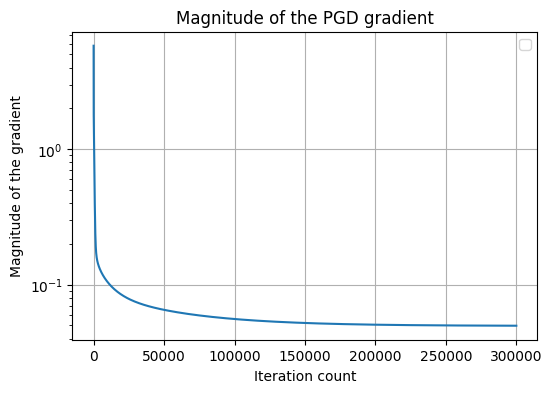

In [17]:
## your code here ##

plt.figure(figsize=(6, 4))
plt.semilogy(range(len(grads_pgd)), grads_pgd)
plt.xlabel("Iteration count")
plt.ylabel("Magnitude of the gradient")
plt.title("Magnitude of the PGD gradient")
plt.grid(True)
plt.legend()
plt.show()



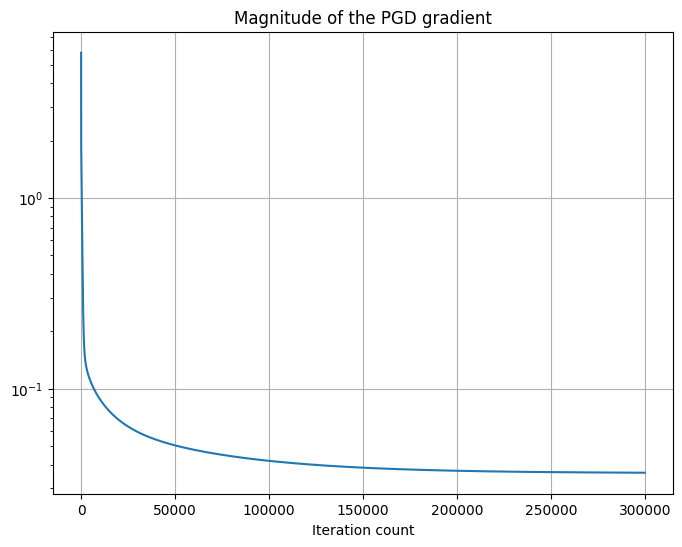

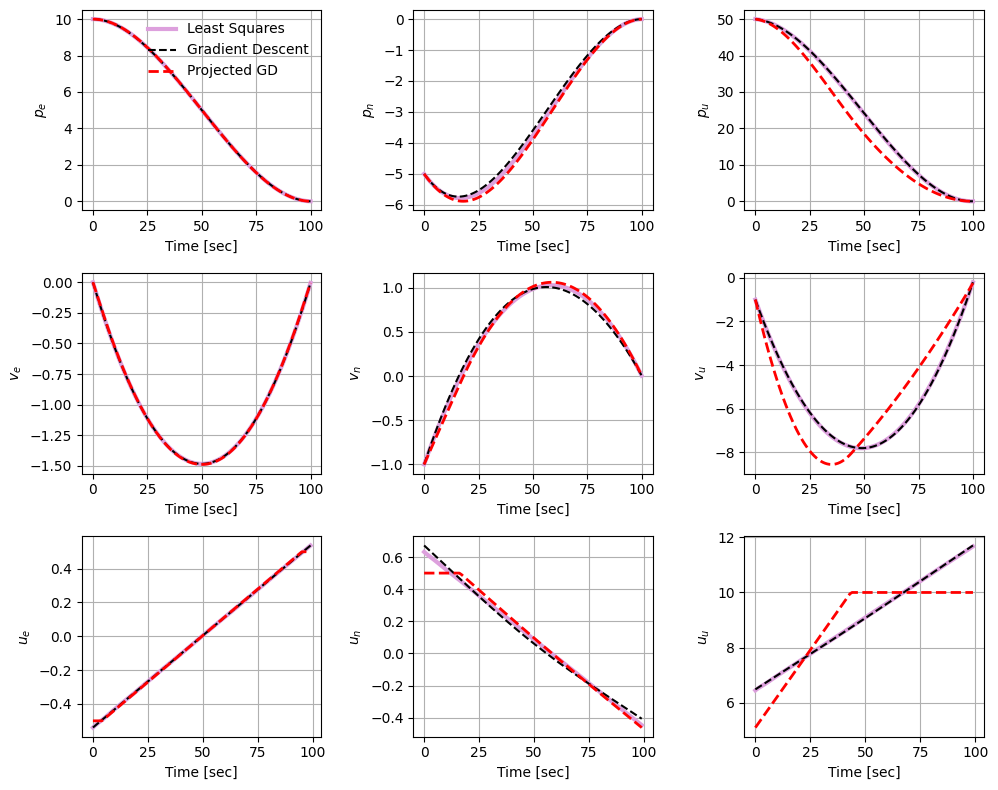

In [14]:
## your code here ##

t_state = np.linspace(0, N, N+1)   # x_0 .. x_N
t_ctrl  = np.linspace(0, N-1, N)   # u_0 .. u_{N-1}

fig, axs = plt.subplots(3, 3, figsize=(10, 8))

items = [
    (r"$p_e$", x_ls[:,0], x_gd[:,0], x_pgd_full[:,0], t_state),
    (r"$p_n$", x_ls[:,1], x_gd[:,1], x_pgd_full[:,1], t_state),
    (r"$p_u$", x_ls[:,2], x_gd[:,2], x_pgd_full[:,2], t_state),
    (r"$v_e$", x_ls[:,3], x_gd[:,3], x_pgd_full[:,3], t_state),
    (r"$v_n$", x_ls[:,4], x_gd[:,4], x_pgd_full[:,4], t_state),
    (r"$v_u$", x_ls[:,5], x_gd[:,5], x_pgd_full[:,5], t_state),
    (r"$u_e$", u_ls[:,0], u_gd[:,0], u_pgd[:,0], t_ctrl),
    (r"$u_n$", u_ls[:,1], u_gd[:,1], u_pgd[:,1], t_ctrl),
    (r"$u_u$", u_ls[:,2], u_gd[:,2], u_pgd[:,2], t_ctrl),
]

for idx, (name, ls_traj, gd_traj, pgd_traj, tt) in enumerate(items):
    r, c = divmod(idx, 3)
    ax = axs[r, c]

    ax.plot(tt, ls_traj,  color="plum", linewidth=3, label="Least Squares")
    ax.plot(tt, gd_traj,  "k--", linewidth=1.5, label="Gradient Descent")
    ax.plot(tt, pgd_traj, "r--", linewidth=2.0, label="Projected GD")

    ax.set_xlabel("Time [sec]")
    ax.set_ylabel(name)
    ax.grid(True)
    if idx == 0:
        ax.legend(frameon=False)

fig.tight_layout()
plt.show()


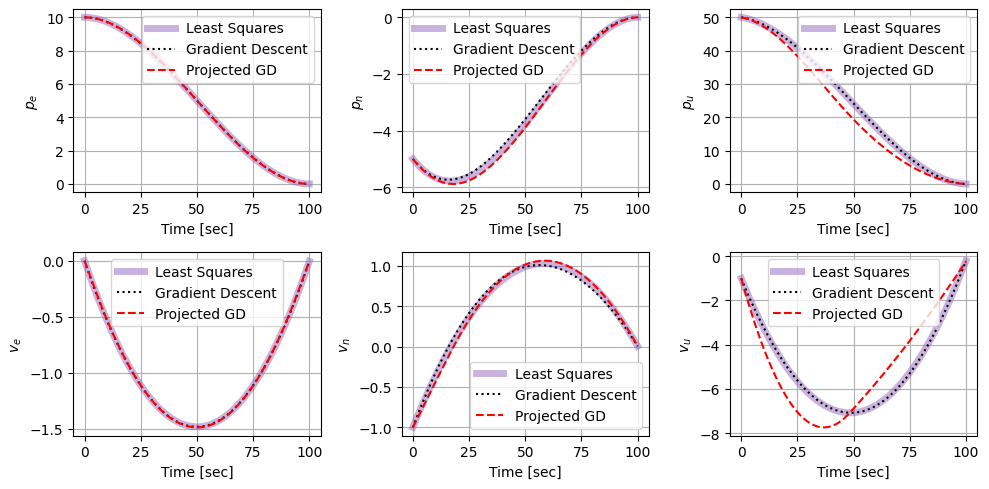
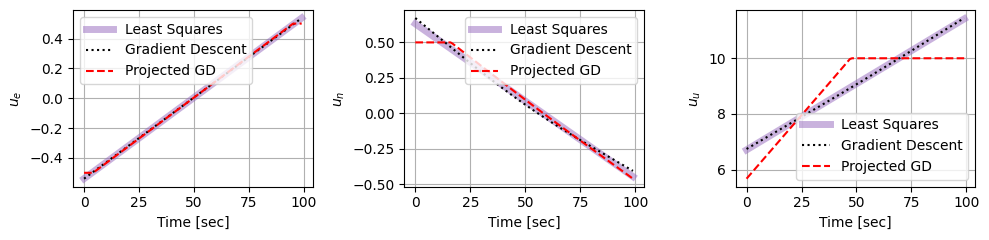

<br>

---

<br>

_**(Problem 5)**_
Extract the optimal position trajectory from the PGD solution and create a 3D plot to visualize the lander's path, comparing it with the unconstrained (Least Squares) solution.

First, extract the position components $(p_e, p_n, p_u)$ from both the `x_pgd` (Projected Gradient Descent) and `x_opt` (Least Squares) arrays for plotting. These correspond to the first three columns of the state vectors.

Import `Axes3D` and create a 3D plot to visualize and compare the optimal trajectories from the PGD and Least Squares solutions, as specified in the instructions.


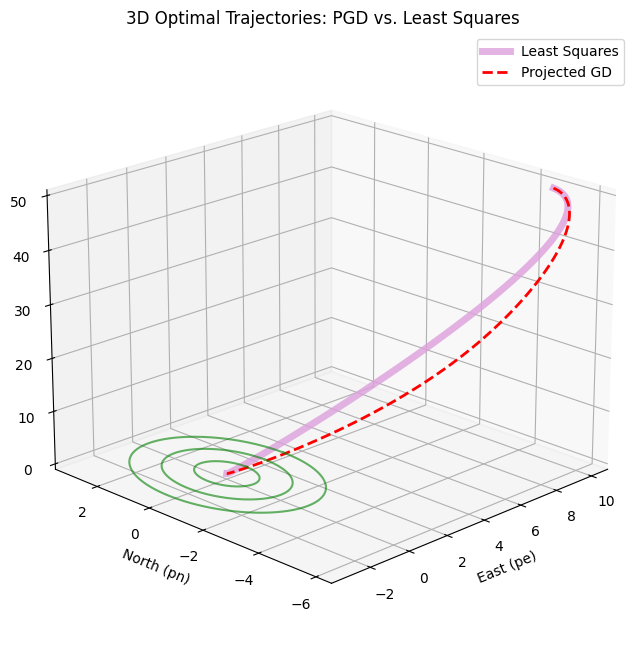

In [15]:
## your code here ##
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# 위치 성분 (p_e, p_n, p_u)만 추출
pos_pgd = x_pgd_full[:, :3]   # Projected GD
pos_ls  = x_ls[:, :3]         # Least Squares (unconstrained)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Least Squares 궤적 (굵은 보라색)
ax.plot(
    pos_ls[:, 0],
    pos_ls[:, 1],
    pos_ls[:, 2],
    color="plum",
    linewidth=5,
    alpha=0.8,
    label="Least Squares",
)

# PGD 궤적 (빨간 점선)
ax.plot(
    pos_pgd[:, 0],
    pos_pgd[:, 1],
    pos_pgd[:, 2],
    "r--",
    linewidth=2.0,
    label="Projected GD",
)

# 착륙 타깃 주변의 그린 서클
theta = np.linspace(0.0, 2.0 * np.pi, 200)
for rad in [1.0, 2.0, 3.0]:
    x_circle = rad * np.cos(theta)
    y_circle = rad * np.sin(theta)
    z_circle = np.zeros_like(theta)
    ax.plot(x_circle, y_circle, z_circle, color="green", alpha=0.6)

ax.set_xlabel("East (pe)")
ax.set_ylabel("North (pn)")
ax.set_zlabel("Up (nd)")
ax.set_title("3D Optimal Trajectories: PGD vs. Least Squares")

ax.legend(loc="upper right")

# 시점(카메라) 각도 약간 조정
ax.view_init(elev=20, azim=-135)

plt.show()


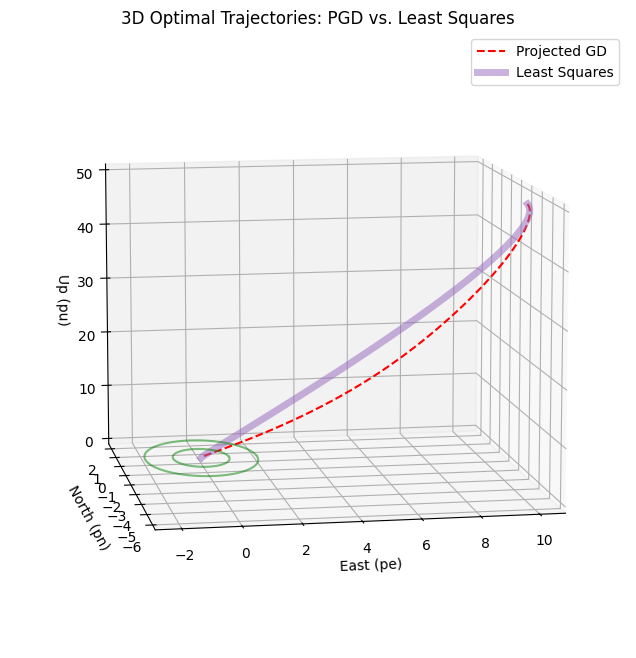

<br>

---

<br>

## Summary and Discussion

<br>

---

<br>

_**(Problem 6)**_
Summarize the results, comparing the unconstrained and constrained solutions, and discussing the implications of adding constraints and using projected gradient descent.


r# your answers here


1. Unconstrained Optimization (Least Squares / Gradient Descent / JAX-GD)

- 동역학 제약을 모두 하나의 선형 시스템 G y = c 형태로 구성하여 Least Squares(LS) 문제로 설정하였다.
- LS의 해와 Gradient Descent(GD), JAX-GD 결과는 거의 완전히 동일하다.
  - 문제 구조가 선형 + 이차형(Convex Quadratic) 이므로 해가 유일
  - GD/JAX-GD는 LS 해에 정확히 수렴
- 상태($p_e, p_n, p_u, v_e, v_n, v_u$)와 제어 입력($u_e, u_n, u_u$) 그래프에서도 LS와 GD 결과는 완전히 겹친다.
- Gradient norm 역시 빠르게 감소하여 약 $10^{-4}$ 수준에 도달한다.

→ 즉, 제약이 없는 경우 LS = GD = JAX-GD 로 동일한 최적해를 제공한다.

2. Constrained Optimization (Projected Gradient Descent, PGD)

- 제어 입력 u에 대해 상하한 제약(Box Constraint)을 적용하여 물리적 제어 한계를 반영하였다.
- PGD 알고리즘:  
  1. GD 방식으로 한 스텝 이동  
  2. 제약을 넘는 입력을 clip()으로 투영(Projection)

- 제약이 활성화되면서 특히 수직 제어 입력 u_u가 포화(saturation) 되고, LS/GD 해와는 다른 궤적이 생성된다.
- Gradient norm은 제약 활성화로 인해 0으로 수렴하지 않고 plateau를 형성한다.  
  - 이는 KKT 조건상 정상적인 현상임.
- 3D 궤적에서도  
  - LS 해(보라색)는 매끄러운 최적 경로,  
  - PGD 해(빨간 점선)는 제약된 제어 입력을 반영한 경로  
→ 이 둘은 차이 존재.

3. Conclusion

- LS/GD/JAX-GD  
  - 제약이 없는 이상적인 조건에서 동일한 최적해를 제공함.
- PGD(제약 적용)  
  - 제어 한계를 만족하는 실제 가능한 궤적을 생성하며,  
  - 일부 제어 입력이 포화됨에 따라 LS와 다른 궤적을 나타낸다.
- 실제 항공우주 분야에서의 착륙 문제는 물리 제약을 반영한 PGD 해가 더 현실적인 논의로 이어진다!

